In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Check shape
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [2]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

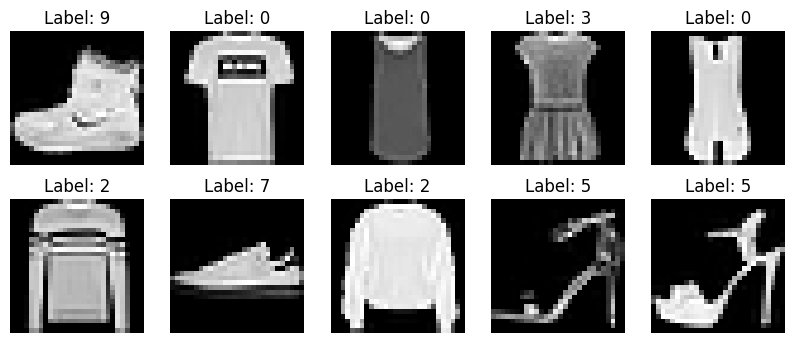

In [3]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [5]:
# Flatten images: 28x28 → 784
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

print("Flattened training shape:", x_train_flat.shape)

Flattened training shape: (60000, 784)


In [6]:
# Input layer
input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(256, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
bottleneck = layers.Dense(2, activation='linear')(encoded)  # 2D embedding

# Decoder
decoded = layers.Dense(64, activation='relu')(bottleneck)
decoded = layers.Dense(256, activation='relu')(decoded)
output_img = layers.Dense(784, activation='sigmoid')(decoded)

# Define the model
autoencoder = models.Model(input_img, output_img)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,858 (1.66 MB)

 Trainable params: 435,858 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0836 - val_loss: 0.0380
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0360 - val_loss: 0.0312
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0310 - val_loss: 0.0296
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0295 - val_loss: 0.0290
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0290 - val_loss: 0.0285
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0285 - val_loss: 0.0281
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0282 - val_loss: 0.0280
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0279 - val_loss: 0.0276
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0277 - val_loss: 0.0275
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0274 - val_loss: 0.0273
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0272 - val_loss: 0.0271
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


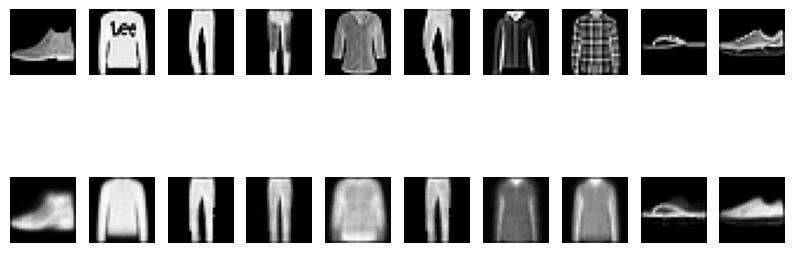

In [8]:
# Take 10 test images
decoded_imgs = autoencoder.predict(x_test_flat[:10])

plt.figure(figsize=(10,4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i+1)
    plt.imshow(x_test_flat[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, 10, i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

In [12]:
# Create encoder model separately
encoder = models.Model(input_img, bottleneck)

# Get embeddings for all test images
embeddings = encoder.predict(x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


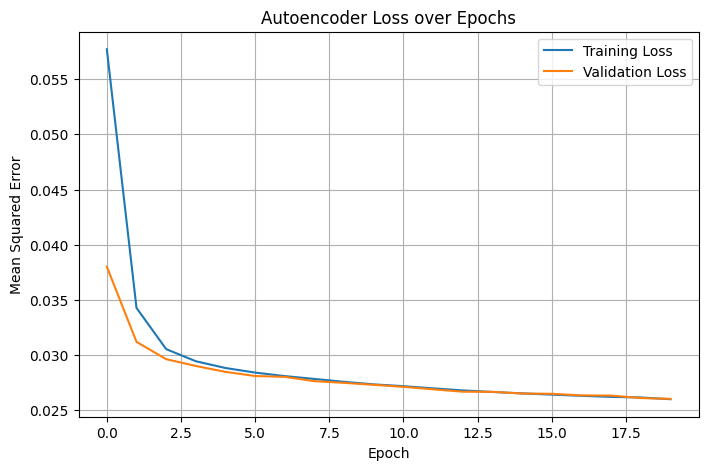

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

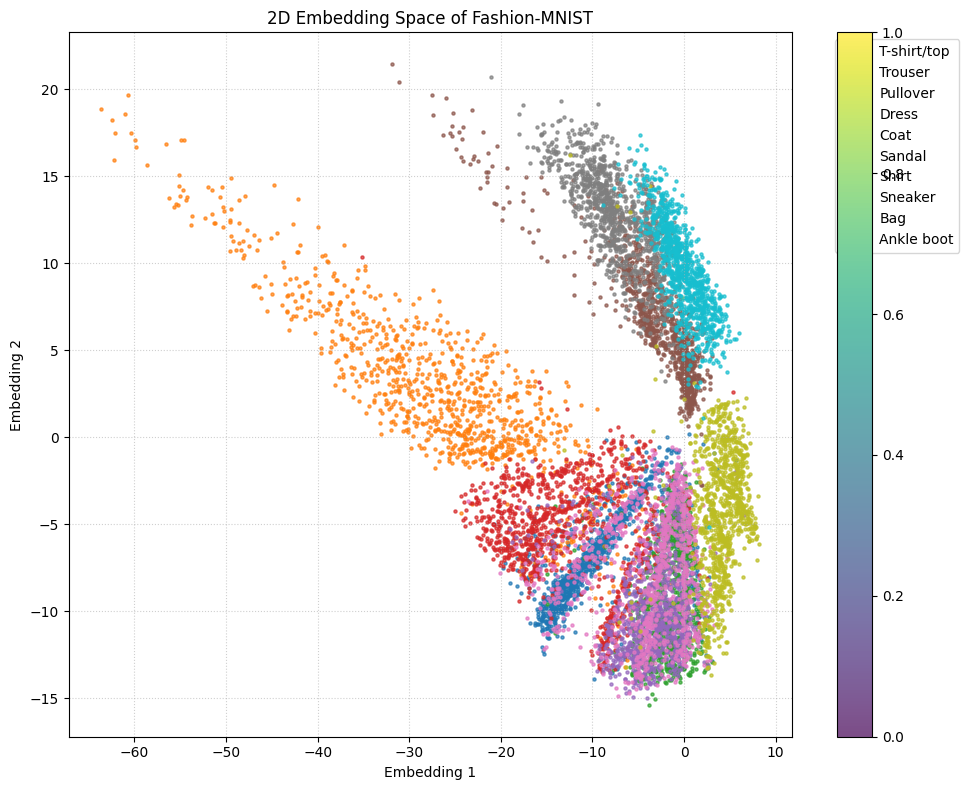

In [13]:
# Define class names for Fashion MNIST
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10, 8))
# Use a loop to plot each class separately to create a proper legend
for i in range(10):
    indices = y_test == i
    plt.scatter(embeddings[indices, 0], embeddings[indices, 1], label=class_names[i], s=5, alpha=0.7)

plt.colorbar()
plt.xlabel('Embedding 1')
plt.ylabel('Embedding 2')
plt.title('2D Embedding Space of Fashion-MNIST')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()